In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

Mass matrix initialization completed
Stiffness matrix initialization completed


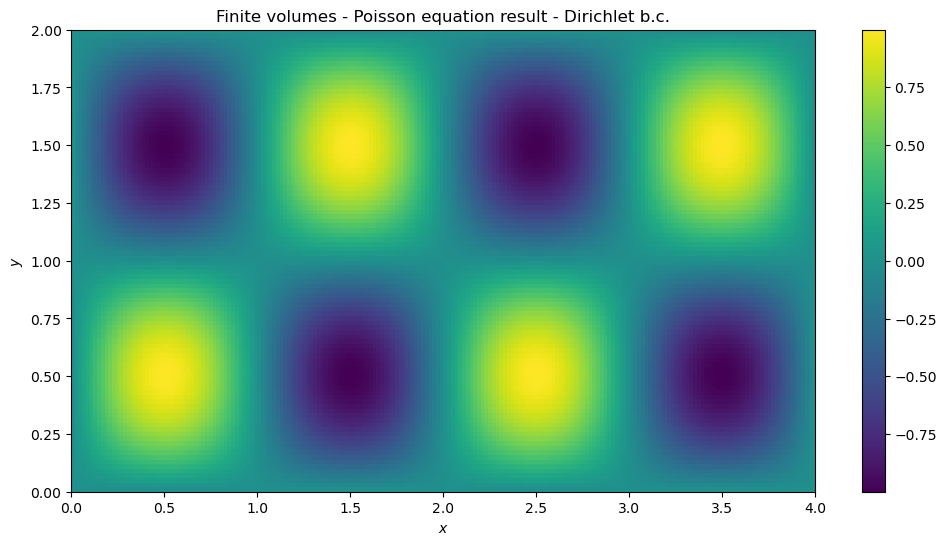

In [2]:
# As a reference solution, first compute the solution with the finite differences methods

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

func = lambda x,y: 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
diri = lambda x,y: 0
res = mymesh.run_simulation_poisson_dirichlet(func, diri)

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite volumes - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson.png')


In [3]:
# Example of a basic case for automatic differentiation with PyTorch

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
# y.backward() saves the gradient back on x. Note that backward destryos the graph, so if I want to apply the graph another time I have to add retain_graph = True
print(x.grad)

tensor(6.)


In [ ]:
f_poisson_torch = lambda x: 2.0 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

trial_PINN = PINN_Poisson_2d(32, f_poisson_torch, lambda x: 0)
# attention, the Dirichlet and Poisson functions take lists [x, y] as inputs
trial_PINN.set_collocation_points(200, (0,4), (0,2))
trial_PINN.compute_boundary_values(10, (0,4), (0,2))
print(trial_PINN.compute_physics_loss())

print(trial_PINN.boundary_points)
print(trial_PINN.boundary_values)



RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.